# Panorama previews: which class per cell?

The panel's preview (`GET /api/panorama.png`, `rust/src/panorama.rs`) colours each ray by the ASPRS class of the 0.5 m cell it hits. The altitude of a cell is its **highest** point, but the class can be chosen in several ways. Three rules are compared here:

| rule | class of a cell |
|---|---|
| `majority` | the most common class of its points (what `export-u16.ipynb` writes now) |
| `highest` | the class of its highest point, the one its altitude comes from |
| `highest-assigned` | the class of its highest point that is not *unassigned* (1); unassigned only if the cell has nothing else |

A horizontal ray enters a building or a tree through the cell at its outer edge. Under `majority`, most returns in that cell are the street or the ground under the canopy, so facades and trunks come out as ground. `highest` follows the surface the ray actually hits, but on buildings the highest returns are often *unassigned* (walls, rooftop equipment). `highest-assigned` skips those.

**Data.** `~/data/lidar-vancouver-u16-classes` is the full `majority` export. The other rules were computed on the JupyterHub server (the raw LiDAR lives there) for a light sample only, into `~/data/class-rules/<rule>/<NAME>.cls`: the 3×3 tiles around Kitsilano Beach, and the tile each other area stands in (about ±500 m, which covers what fills a street-level view). Everywhere else those variants fall back to the `majority` classes, so distant pixels may still show the majority rule.

In [1]:
import gc
import io
import os
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from viewfinder_core import RayResult, RayTracer
from app.view import (OBSERVER_HEIGHT, PANORAMA_MAX_ELEVATION, PANORAMA_MIN_ELEVATION,
                      PANORAMA_PIXELS_PER_DEGREE, observer_position, panorama_png)

data_path = pathlib.Path("~/data").expanduser()
majority_path = data_path / "lidar-vancouver-u16-classes"
trial_path = data_path / "class-rules"
rules = ["majority", "highest", "highest-assigned"]

areas = {
    "Downtown street": (49.2827, -123.1207),
    "Coal Harbour seawall": (49.2930, -123.1300),
    "Kitsilano Beach": (49.2744, -123.1550),
    "Queen Elizabeth Park": (49.2418, -123.1126),
    "East Van houses": (49.2600, -123.0700),
    "Fraser River": (49.2060, -123.1000),
}

# Same palette as rust/src/panorama.rs
class_colours = {
    1: ("unassigned", (138, 122, 104)), 2: ("ground", (179, 163, 127)), 3: ("low vegetation", (143, 176, 105)),
    5: ("high vegetation", (63, 107, 58)), 6: ("building", (154, 157, 163)), 9: ("water", (63, 116, 163)),
}

In [2]:
def export_for(rule):
    """Export directory for a rule: the majority export, with the trial tiles' class files swapped in.
    Hard links, so it costs no space; rebuilt every run so it follows the trial files."""
    if rule == "majority":
        return majority_path
    path = data_path / f"lidar-vancouver-u16-{rule}"
    path.mkdir(exist_ok=True)
    for source in majority_path.iterdir():
        trial = trial_path / rule / source.name
        target = path / source.name
        target.unlink(missing_ok=True)
        os.link(trial if trial.exists() else source, target)
    return path

pd.Series({rule: len(list((trial_path / rule).glob("*.cls"))) if rule != "majority" else "all"
           for rule in rules}, name="tiles with this rule")

majority            all
highest              16
highest-assigned     16
Name: tiles with this rule, dtype: object

## Previews

One row per rule, as the panel shows them: the full circle from north (left) clockwise, −10° to +20° elevation, from eye level (`OBSERVER_HEIGHT` above the surface). Each grid needs ~4 GB, so the rules are loaded one at a time.

In [3]:
images = {}  # (area, rule) -> RGB array
hits = []  # class of every ray that hits something, per area and rule
for rule in rules:
    rt = RayTracer(export_for(rule))
    for area, (latitude, longitude) in areas.items():
        images[area, rule] = plt.imread(io.BytesIO(panorama_png(rt, latitude, longitude)))
        x, y, ground = observer_position(rt, latitude, longitude)
        width = 360 * PANORAMA_PIXELS_PER_DEGREE
        height = (PANORAMA_MAX_ELEVATION - PANORAMA_MIN_ELEVATION) * PANORAMA_PIXELS_PER_DEGREE
        columns = rt.ray_collisions_around(x, y, ground + OBSERVER_HEIGHT, np.radians(PANORAMA_MIN_ELEVATION),
                                           np.radians(PANORAMA_MAX_ELEVATION), height, 0.0, 2 * np.pi, width)
        hits += [{"area": area, "rule": rule, "class": r.classification}
                 for column in columns for r in column if isinstance(r, RayResult.Collision)]
    del rt
    gc.collect()

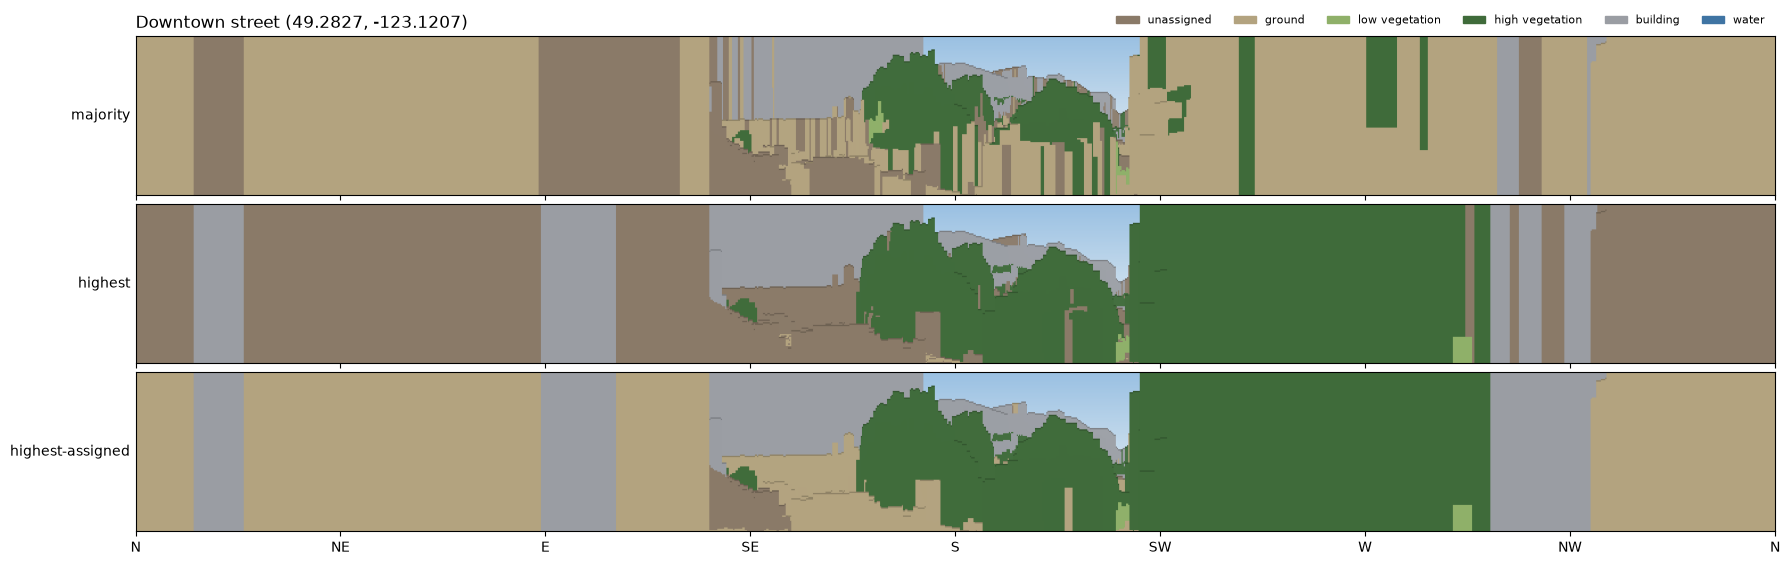

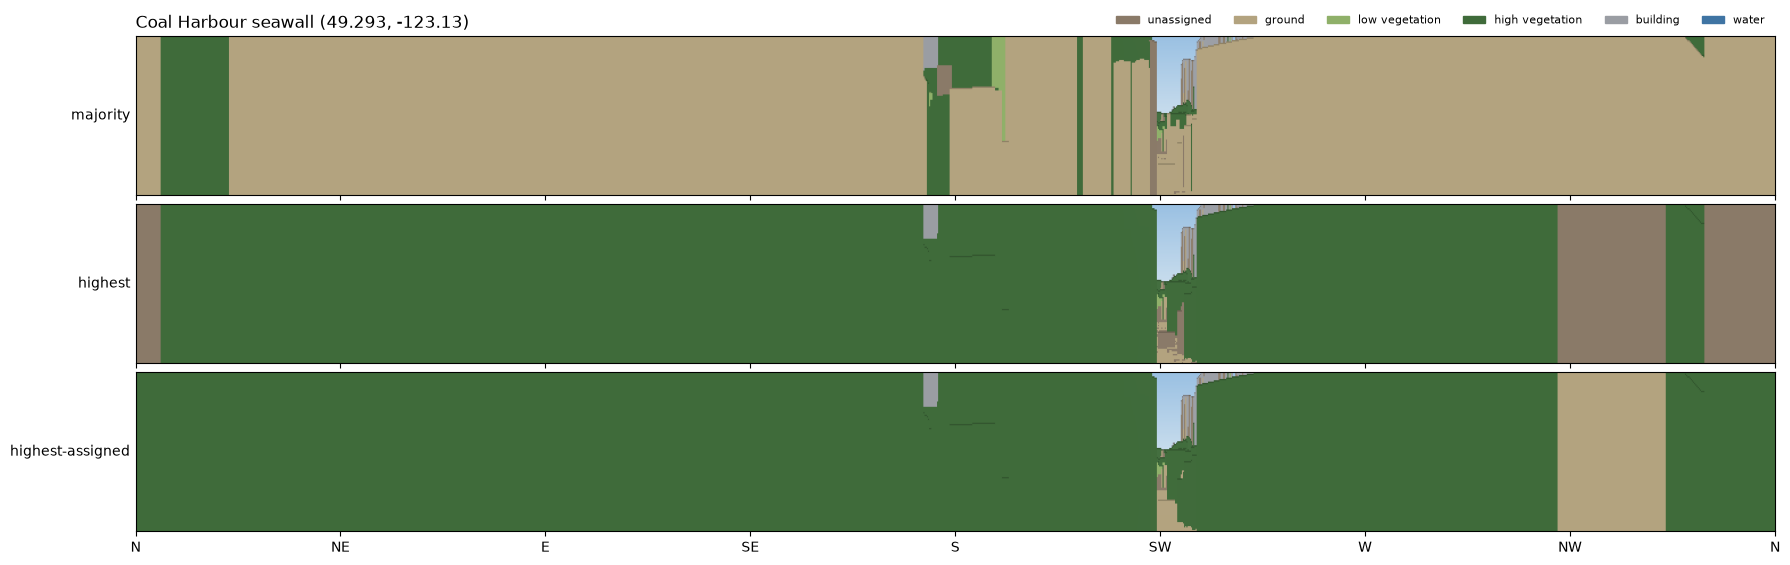

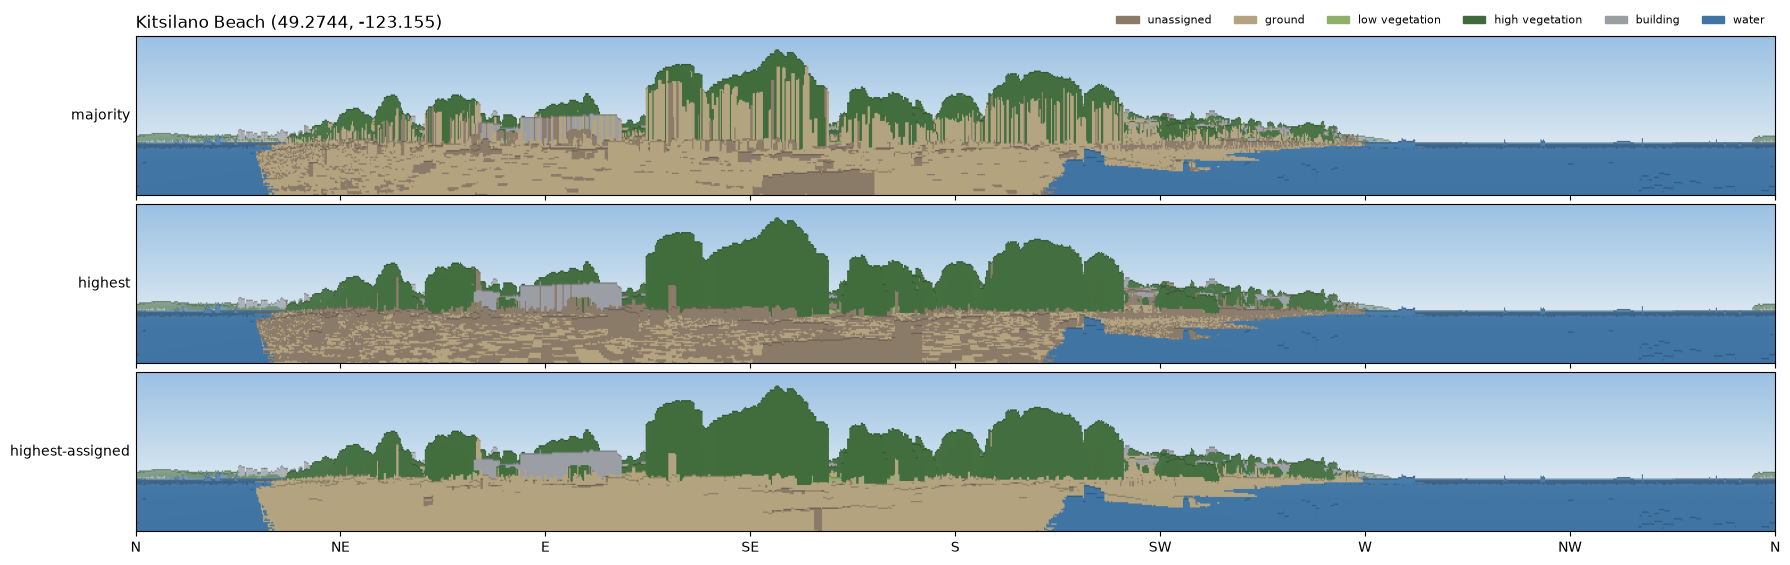

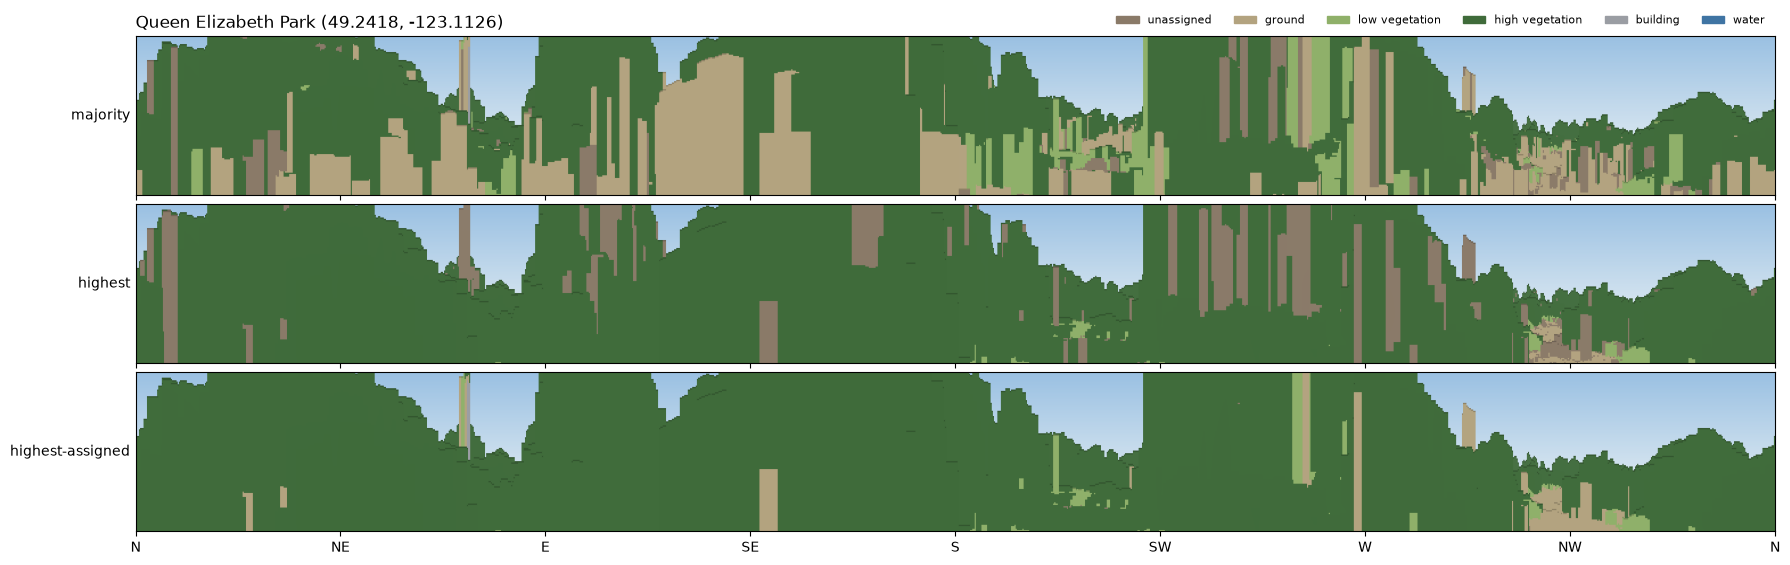

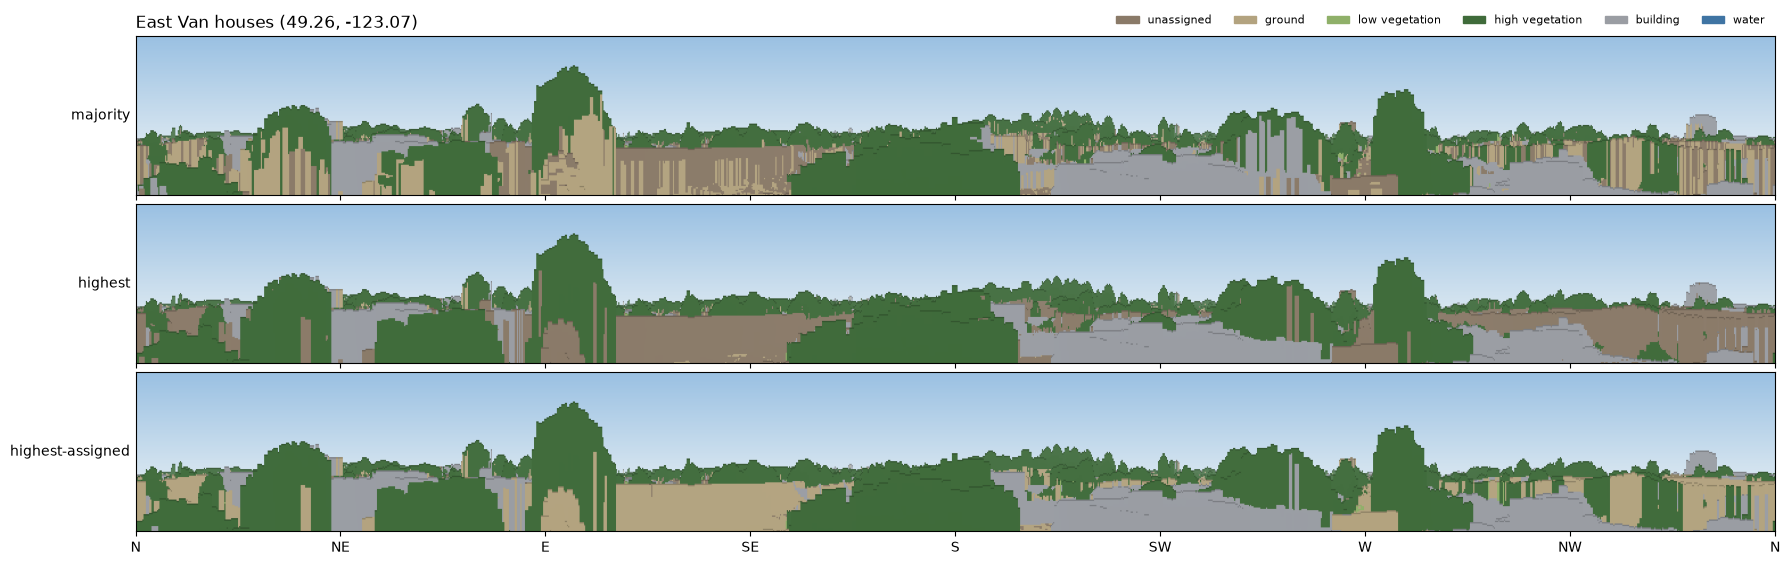

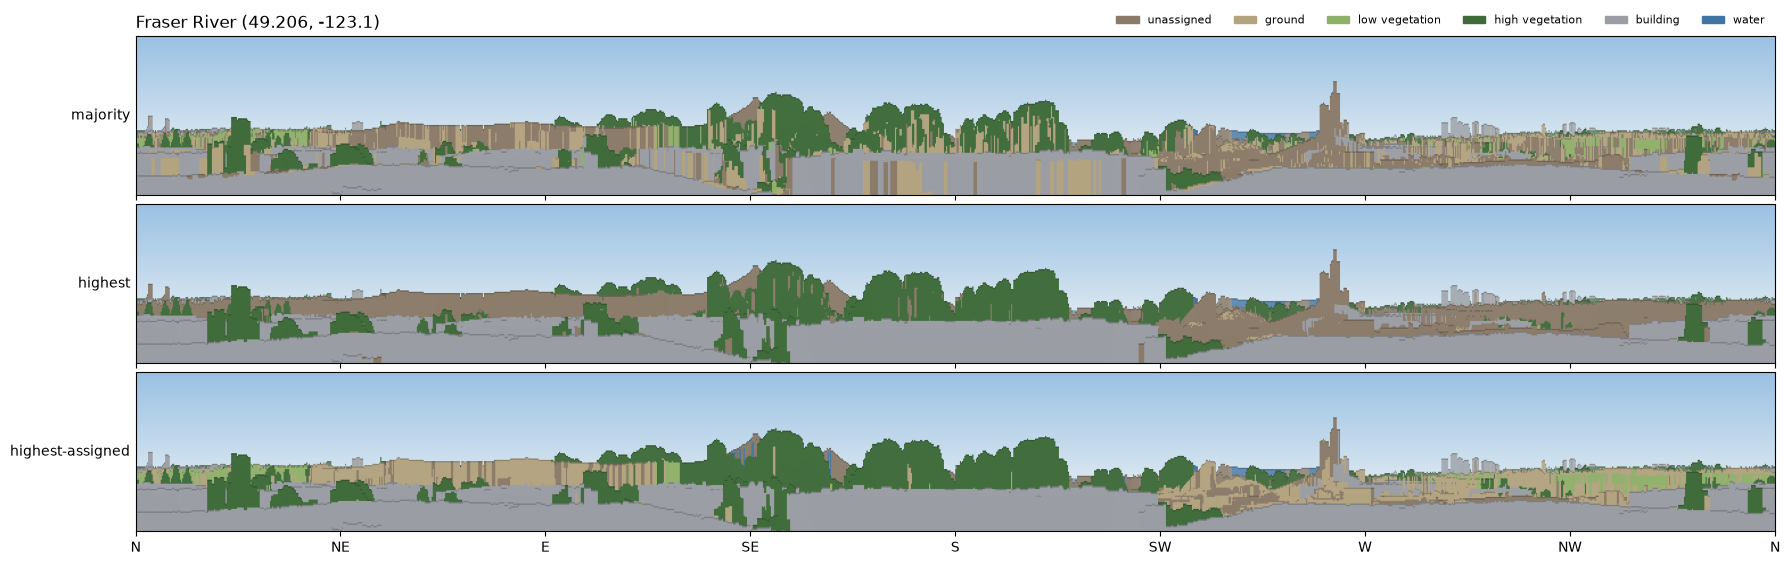

In [4]:
legend = [Patch(color=np.array(rgb) / 255, label=name) for name, rgb in class_colours.values()]
bearings = np.arange(0, 361, 45)
for area in areas:
    fig, axs = plt.subplots(len(rules), 1, figsize=(18, 1.1 + 1.55 * len(rules)), sharex=True)
    for ax, rule in zip(axs, rules):
        ax.imshow(images[area, rule], extent=(0, 360, PANORAMA_MIN_ELEVATION, PANORAMA_MAX_ELEVATION), aspect="auto")
        ax.set_ylabel(rule, rotation=0, ha="right", va="center")
        ax.set_yticks([])
    axs[-1].set_xticks(bearings, ["N", "NE", "E", "SE", "S", "SW", "W", "NW", "N"])
    axs[0].set_title(f"{area} {areas[area]}", loc="left")
    axs[0].legend(handles=legend, ncol=len(legend), loc="lower right", bbox_to_anchor=(1, 1), frameon=False, fontsize=8)
    fig.tight_layout(h_pad=0.3)
    plt.show()

## Share of each class among the pixels that hit something

Per area and rule, the classes of the rays that hit a surface (sky and open water excluded). Ground on a street-level view should mostly be the road ahead, not walls; unassigned says nothing about what was hit.

In [5]:
names = {c: name for c, (name, _) in class_colours.items()}
shares = (pd.DataFrame(hits).assign(name=lambda d: d["class"].map(names).fillna("other"))
          .groupby(["area", "rule"])["name"].value_counts(normalize=True).unstack(fill_value=0) * 100)
shares.loc[list(areas)].round(1).style.format(precision=1).background_gradient(axis=None, cmap="Greys")

## Findings

- **Trees: `highest-assigned` fixes them.** Trunks and canopies are green all the way down (Coal Harbour 92 % high vegetation, Queen Elizabeth Park 95 %), where `majority` painted them as the ground under the canopy (91 % and 23 % ground).
- **Unassigned: gone.** It drops to 0-1.4 % of hits in the city areas (5.5 % on the industrial Fraser River). Under `highest` it was the top class downtown (48 %): the tops of building edges are mostly left unclassified.
- **Building walls: only partly.** Where a wall's edge cell also has a building return (most of East Van south-west, downtown east and north-west) it is now grey. But where every return above the street is unassigned (downtown N-NE, East Van E-SE), `highest-assigned` falls through to the ground return under it, and the wall turns tan again: the downtown street view is still 44 % ground.
- Water and the beach (Kitsilano) are the same under every rule; the ocean cells are forced to water anyway.

**Next idea, not tried yet:** keep `highest-assigned`, but if the chosen class is ground while the cell's highest point (unassigned) stands more than ~2 m above that ground return, call it a building. Walls, cranes and the rooftop equipment over a street would read as built structures instead of road.
